In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress
import itertools as it
from matplotlib import rcParams
import matplotlib.colors as mcolors
from utils.analysis import uq_get_obs, uq_get_sim
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['P07', 'P06', 'P20', 'P13', 'P08', 'P17'],
    'elev': ['P19', 'P11', 'P04', 'P16', 'P10']
}

In [2]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list_uq = ['UQ_20231118', 'UQ_20240112'] # , 'UQ_20240312_test20241017']
N_list = [4000, 4000, 4000]
BLOCK_LIST = [200, 200, 200]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE']
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']

In [3]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list_uq = ['UQ_20231118', 'UQ_20240112'] # , 'UQ_20240312_test20241017']
N_list = [4000, 4000, 4000]
BLOCK_LIST = [200, 200, 200]

collection_obs = uq_get_obs(VAR_SUBSET)

collection_sim = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list_uq):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(
            os.environ['PROJDIR'], 'ELM_Nutrients', 'output', "extract", prefix,
            f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)

    collection_sim[prefix] = collect

In [4]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
sub1 = np.arange(10)
sub2 = np.arange(10,14)
xticklabels = {
    0: [var.replace('_','$_{')+'}$'+f' {co2}' for var in VAR_SUBSET[:5] \
        for co2 in ['', 'CO2']],
    1: [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET[5:] \
        for co2 in ['', 'CO2']],
}
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

# (note: the index values is ensemble_id minus one, because Python index starts
#  from 0, and ensemble id starts from 1)
n_best_ind = 40
best_ind = {'UQ_20231118': 3066, 'UQ_20240107': 1484, 'UQ_20240112': 1943}
#best_ind = {'UQ_20231118': 1180, 'UQ_20240107': 1740, 'UQ_20240112': 1943}


#
obs_mean = collection_obs.values.reshape(-1, 2, 4)[:, :, 0]
obs_mean_std = collection_obs.values.reshape(-1, 2, 4)[:, :, 1]
obs_slope = collection_obs.values.reshape(-1, 2, 4)[:, :, 2]
obs_slope_std = collection_obs.values.reshape(-1, 2, 4)[:, :, 3]


#
sim_mean = {}
sim_mean_std = {}
sim_slope = {}
sim_slope_std = {}
for p, prefix in enumerate(prefix_list_uq):
    # the 2 is ACO2 and ECO2
    sim_mean[prefix] = collection_sim[prefix][best_ind[prefix], ind_list, :][:,:,0]
    sim_mean_std[prefix] = collection_sim[prefix][best_ind[prefix], ind_list, :][:,:,1]
    sim_slope[prefix] = collection_sim[prefix][best_ind[prefix], ind_list, :][:,:,2]
    sim_slope_std[prefix] = collection_sim[prefix][best_ind[prefix], ind_list, :][:,:,3]

#
obs_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                                    'extract_obs_productivity.csv'), index_col = [0, 1])
# - restrict to pre-2021
obs_data = obs_data.loc[obs_data.index.get_level_values('Year') <= 2021, :]
# - re-order
t2m_obs = obs_data.loc[:, 'Tair']
obs_data = obs_data.loc[:, VAR_SUBSET]['AGNPP_Shrub']

In [5]:
labs = 'abcd'
clist = ['#1b249e', '#ff0000']
lss = ["-", "--"]
fcs = ["k", "none"]

ind_agnpp_shrub = np.where([x=='AGNPP_Shrub' for x in VAR_SUBSET])[0][0]

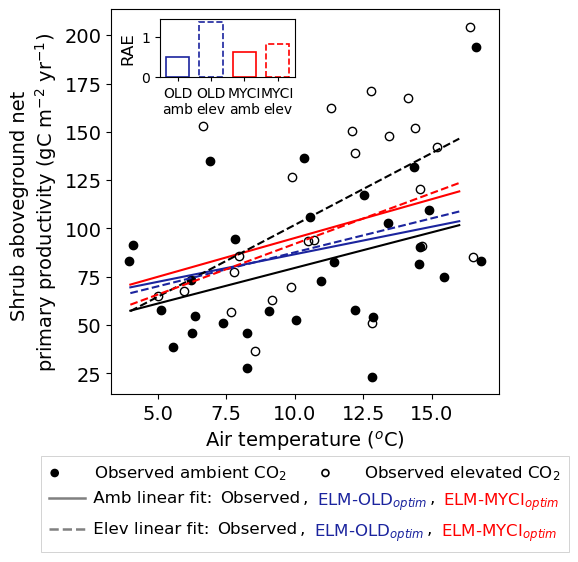

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(5, 5))
rae_vals = {}  # keyed by (prefix, co2) -> RMSE
for i, co2 in enumerate(['amb', 'elev']):
    t_ = t2m_obs.loc[chambers_ordered[co2]]
    y_obs = obs_data.loc[chambers_ordered[co2]]
    ax.plot(t_, y_obs, 'ok', markerfacecolor=fcs[i])
    x = np.linspace(4, 16, 50)  # finer grid for a smooth band
    tmean = np.mean(t_)
    # --- Observed regression line + uncertainty ---
    slope = obs_slope[ind_agnpp_shrub, i]
    slope_std = obs_slope_std[ind_agnpp_shrub, i]
    mean_ = obs_mean[ind_agnpp_shrub, i]
    mean_std = obs_mean_std[ind_agnpp_shrub, i]
    y = mean_ + slope * (x - tmean)
    y_std = np.sqrt(mean_std**2 + (x - tmean)**2 * slope_std**2)
    ax.plot(x, y, 'k', ls=lss[i])
    #ax.fill_between(x, y - y_std, y + y_std, color='k', alpha=0.1-0.05*i, lw=0)
    # --- Simulated regression lines + uncertainty ---
    for prefix, c in zip(prefix_list_uq, clist):
        slope = sim_slope[prefix][ind_agnpp_shrub, i]
        slope_std = sim_slope_std[prefix][ind_agnpp_shrub, i]
        mean_ = sim_mean[prefix][ind_agnpp_shrub, i]
        mean_std = sim_mean_std[prefix][ind_agnpp_shrub, i]
        y = mean_ + slope * (x - tmean)
        y_std = np.sqrt(mean_std**2 + (x - tmean)**2 * slope_std**2)
        ax.plot(x, y, color=c, ls=lss[i])
        #ax.fill_between(x, y - y_std, y + y_std, color=c, alpha=0.1-0.05*i, lw=0)
        rae = np.abs(mean_ - obs_mean[ind_agnpp_shrub,i]) / obs_mean_std[ind_agnpp_shrub, i] + \
                   np.abs(slope - obs_slope[ind_agnpp_shrub,i]) / obs_slope_std[ind_agnpp_shrub, i]
        rae_vals[(prefix, co2)] = rae
ax.set_xlabel('Air temperature ($^o$C)')
ax.set_ylabel('Shrub aboveground net \nprimary productivity (gC m$^{-2}$ yr$^{-1}$)')

def reorder_for_rows(handles, ncols):
    """Reorder handles (given in desired row-major reading order)
    into the column-major order matplotlib's legend() expects."""
    n = len(handles)
    nrows = -(-n // ncols)  # ceil division
    padded = handles + [None] * (nrows * ncols - n)
    grid = [padded[i*ncols:(i+1)*ncols] for i in range(nrows)]
    col_major = [grid[r][c] for c in range(ncols) for r in range(nrows)]
    return [h for h in col_major if h is not None]

from matplotlib.offsetbox import DrawingArea, TextArea, HPacker, VPacker, AnnotationBbox
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

def marker_dot(color, filled=True, size=8):
    da = DrawingArea(size, size, 0, 0)
    da.add_artist(Circle((size/2, size/2), size/2 - 1.5,
                          facecolor=color if filled else 'none',
                          edgecolor='k', linewidth=1.2))
    return da

def marker_line(color, ls='-', width=26, height=10):
    da = DrawingArea(width, height, 0, 0)
    da.add_artist(Line2D([0, width], [height/2, height/2], color=color, ls=ls, lw=1.8))
    return da

def txt(s, color='k', fontsize=12):
    return TextArea(s, textprops=dict(color=color, fontsize=fontsize))

# --- Row 1: observed markers ---
row1 = HPacker(children=[
    marker_dot('k', filled=True), txt('Observed ambient CO$_2$'),
    marker_dot('k', filled=False), txt('Observed elevated CO$_2$'),
], align='center', pad=0, sep=24)

# --- Row 2: ambient linear fit (solid grey), multi-color labels ---
row2 = HPacker(children=[
    marker_line('grey', ls='-'), txt(' Amb linear fit: '),
    txt('Observed', 'k'), txt(', '),
    txt('ELM-OLD$_{optim}$', clist[0]), txt(', '),
    txt('ELM-MYCI$_{optim}$', clist[1]),
], align='top', pad=0, sep=2)

# --- Row 3: elevated linear fit (dashed grey), multi-color labels ---
row3 = HPacker(children=[
    marker_line('grey', ls='--'), txt(' Elev linear fit: '),
    txt('Observed', 'k'), txt(', '),
    txt('ELM-OLD$_{optim}$', clist[0]), txt(', '),
    txt('ELM-MYCI$_{optim}$', clist[1]),
], align='top', pad=0, sep=2)

vbox = VPacker(children=[row1, row2, row3], align='left', pad=0, sep=6)

ab = AnnotationBbox(vbox, (0.5, -0.18), xycoords='axes fraction',
                     box_alignment=(0.5, 1), frameon=True,
                     bboxprops=dict(edgecolor='k', linewidth=0.6, alpha=0.2))
ax.add_artist(ab)

# --- Inset bar plot of RAE for the four simulated regression lines ---
axins = inset_axes(ax, width='35%', height='15%', loc='upper left', bbox_to_anchor=(0.1, 0, 1, 1),
                   bbox_transform=ax.transAxes)

bar_labels = [f'{p}\n{co2}' for p in ['OLD','MYCI'] for co2 in ['amb', 'elev']]
bar_values = [rae_vals[(p, co2)] for p in prefix_list_uq for co2 in ['amb', 'elev']]
bar_colors = [c for c in clist for _ in range(2)]
bar_ls = [lss[j] for p in prefix_list_uq for j in range(2)]  # solid for amb, dashed for elev

bars = axins.bar(range(len(bar_values)), bar_values, facecolor='none',
                  edgecolor=bar_colors, linewidth=1.2, width=0.7)

# set linestyle per bar individually (bar() doesn't reliably broadcast linestyle lists)
for bar, ls in zip(bars, bar_ls):
    bar.set_linestyle(ls)

axins.set_xticks(range(len(bar_values)))
axins.set_xticklabels(bar_labels, fontsize=10)
axins.set_ylabel('RAE', fontsize=12)
axins.tick_params(axis='y', labelsize=10)
axins.tick_params(axis='x', length=3)

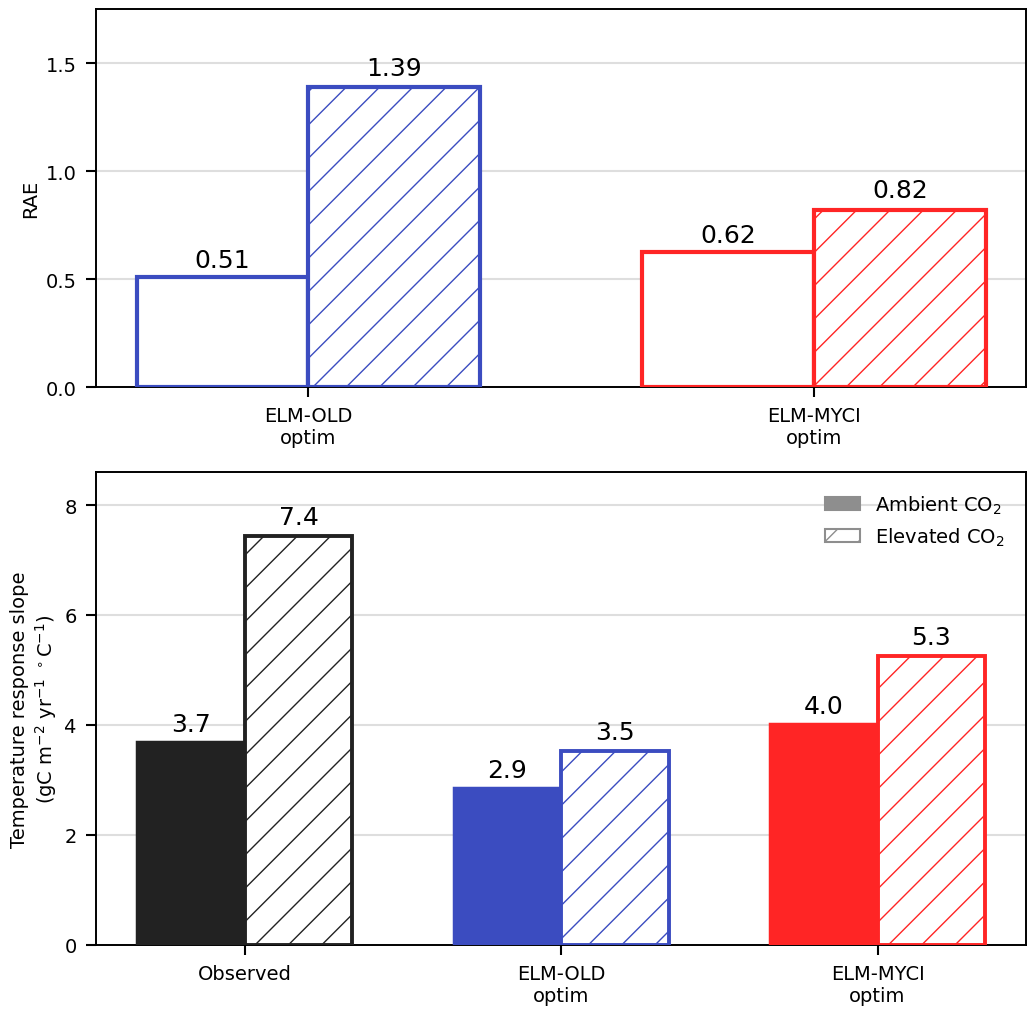

In [47]:
BLUE = "#3B4CC0"
RED = "#FF2525"
BLACK = "#222222"
GRID = "#DEDEDE"

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(12, 12.15), gridspec_kw={"height_ratios": [1.0, 1.25]})

# Shared axis appearance.
for ax in (ax_top, ax_bottom):
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRID, linewidth=1.5)
    ax.xaxis.grid(False)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.4)

    ax.tick_params(axis="both", which="major", direction="out", length=7, width=1.5, pad=7)

# ------------------------------ Upper panel -------------------------------

groups_top = np.arange(2)
bar_width_top = 0.34

ambient_rae = [rae_vals[('UQ_20231118','amb')], rae_vals[('UQ_20240112','amb')]] # default, myci
elevated_rae = [rae_vals[('UQ_20231118','elev')], rae_vals[('UQ_20240112','elev')]]
top_colors = [BLUE, RED]

for x, ambient, elevated, color in zip(groups_top, ambient_rae, elevated_rae, top_colors):
    left_bar = ax_top.bar(
        x - bar_width_top / 2,
        ambient,
        width=bar_width_top,
        facecolor="white",
        edgecolor=color,
        linewidth=3.0,
        zorder=3,
    )[0]

    right_bar = ax_top.bar(
        x + bar_width_top / 2,
        elevated,
        width=bar_width_top,
        facecolor="white",
        edgecolor=color,
        linewidth=3.0,
        hatch="/",
        zorder=3,
    )[0]

    ax_top.text(
        left_bar.get_x() + left_bar.get_width() / 2,
        ambient + 0.025,
        f"{ambient:.2f}",
        ha="center",
        va="bottom",
        fontsize=18,
    )

    ax_top.text(
        right_bar.get_x() + right_bar.get_width() / 2,
        elevated + 0.035,
        f"{elevated:.2f}",
        ha="center",
        va="bottom",
        fontsize=18,
    )

ax_top.set_ylabel("RAE")
ax_top.set_xticks(groups_top)
ax_top.set_xticklabels(["ELM-OLD\noptim", "ELM-MYCI\noptim"])
ax_top.set_ylim(0, 1.75)
ax_top.set_yticks([0.0, 0.5, 1.0, 1.5])
ax_top.set_xlim(-0.42, 1.42)

# ------------------------------ Lower panel -------------------------------

groups_bottom = np.arange(3)
bar_width_bottom = 0.34

ambient_slopes = [obs_slope[ind_agnpp_shrub, 0], sim_slope['UQ_20231118'][ind_agnpp_shrub, 0], sim_slope['UQ_20240112'][ind_agnpp_shrub, 0]]
elevated_slopes = [obs_slope[ind_agnpp_shrub, 1], sim_slope['UQ_20231118'][ind_agnpp_shrub, 1], sim_slope['UQ_20240112'][ind_agnpp_shrub, 1]]
bottom_colors = [BLACK, BLUE, RED]

for x, ambient, elevated, color in zip(groups_bottom, ambient_slopes, elevated_slopes, bottom_colors):
    left_bar = ax_bottom.bar(
        x - bar_width_bottom / 2,
        ambient,
        width=bar_width_bottom,
        facecolor=color,
        edgecolor=color,
        linewidth=2.5,
        zorder=3,
    )[0]

    right_bar = ax_bottom.bar(
        x + bar_width_bottom / 2,
        elevated,
        width=bar_width_bottom,
        facecolor="white",
        edgecolor=color,
        linewidth=2.8,
        hatch="/",
        zorder=3,
    )[0]

    ax_bottom.text(
        left_bar.get_x() + left_bar.get_width() / 2,
        ambient + 0.10,
        f"{ambient:.1f}",
        ha="center",
        va="bottom",
        fontsize=18,
    )

    ax_bottom.text(
        right_bar.get_x() + right_bar.get_width() / 2,
        elevated + 0.12,
        f"{elevated:.1f}",
        ha="center",
        va="bottom",
        fontsize=18,
    )

ax_bottom.set_ylabel(
    "Temperature response slope\n"
    r"($\mathrm{gC\ m^{-2}\ yr^{-1}\ ^\circ C^{-1}}$)"
)
ax_bottom.set_xticks(groups_bottom)
ax_bottom.set_xticklabels(["Observed", "ELM-OLD\noptim", "ELM-MYCI\noptim"])
ax_bottom.set_ylim(0, 8.6)
ax_bottom.set_yticks([0, 2, 4, 6, 8])
ax_bottom.set_xlim(-0.47, 2.47)

# The reference legend uses neutral gray samples instead of the group colors.
legend_handles = [
    Patch(
        facecolor="#8E8E8E",
        edgecolor="#8E8E8E",
        linewidth=1.5,
        label=r"Ambient CO$_2$",
    ),
    Patch(
        facecolor="white",
        edgecolor="#8E8E8E",
        linewidth=1.5,
        hatch="/",
        label=r"Elevated CO$_2$",
    ),
]

ax_bottom.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    borderaxespad=0.7,
    handlelength=1.8,
)